Loss:
adjustable ordinal loss

In [1]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "models").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("models exists:", (PROJECT_ROOT / "models").exists())
print("utils exists:", (PROJECT_ROOT / "utils").exists())



Current path: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\notebook
Project root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1
models exists: True
utils exists: True


In [2]:
import importlib
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import utils.train_utils
import models.loss_funcs

importlib.reload(utils.train_utils)
importlib.reload(models.loss_funcs)

from utils.dataset import get_dataloaders, print_dataset_info
from models.densenet import get_densenet121, count_trainable_parameters
from models.loss_funcs import ChenOrdinalLoss
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics, get_confusion_matrix




In [3]:
EXPERIMENT_NAME = "densenet121_chen_ordinal_loss"

NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
MAX_EPOCHS = 30
PATIENCE = 7
MONITOR_METRIC = "qwk"

PENALTY_DISTANCE = 2
SQUARE_LOSS = True
NORMALIZE_MATRIX = False

print("Experiment:", EXPERIMENT_NAME)
print("Penalty distance:", PENALTY_DISTANCE)
print("Square loss:", SQUARE_LOSS)
print("Normalize matrix:", NORMALIZE_MATRIX)




Experiment: densenet121_chen_ordinal_loss
Penalty distance: 2
Square loss: True
Normalize matrix: False


In [4]:
from models.loss_funcs import ChenOrdinalLoss

criterion_check = ChenOrdinalLoss(
    num_classes=5,
    penalty_distance=2,
    square_loss=True,
    normalize=False,
)

print(criterion_check.penalty_matrix)




tensor([[0., 3., 5., 7., 9.],
        [3., 0., 3., 5., 7.],
        [5., 3., 0., 3., 5.],
        [7., 5., 3., 0., 3.],
        [9., 7., 5., 3., 0.]])


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))



Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [6]:
SPLIT_ROOT = PROJECT_ROOT / "data" / "processed" / "split_images"

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = get_dataloaders(
    split_root=SPLIT_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    use_augmentation=True,
)

print_dataset_info(train_dataset, val_dataset, test_dataset)

class_names = train_dataset.classes


Dataset Information
Train images: 1024
Val images:   146
Test images:  294

Class to index mapping:
{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

Classes:
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']


In [7]:
model = get_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
)

model = model.to(device)

trainable_params, total_params = count_trainable_parameters(model)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")


Trainable parameters: 6,958,981
Total parameters:     6,958,981


In [8]:
criterion = ChenOrdinalLoss(
    num_classes=NUM_CLASSES,
    penalty_distance=PENALTY_DISTANCE,
    square_loss=SQUARE_LOSS,
    normalize=NORMALIZE_MATRIX,
)
criterion = criterion.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)




In [9]:
SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=MAX_EPOCHS,
    save_path=SAVE_PATH,
    monitor_metric=MONITOR_METRIC,
    patience=PATIENCE,
    min_delta=1e-4,
)



Epoch 1/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 11.3931 | Train Acc: 0.3711 | Train Macro F1: 0.2956 | Train QWK: 0.4152
Val Loss:   7.2295 | Val Acc:   0.5068 | Val Macro F1: 0.3808 | Val QWK:   0.7053 | Val MAE:   0.6575
New best model found at epoch 1.
Best val qwk: 0.7053
Saved best model to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_chen_ordinal_loss.pth

Epoch 2/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.5781 | Train Acc: 0.9482 | Train Macro F1: 0.9461 | Train QWK: 0.9778
Val Loss:   2.3035 | Val Acc:   0.7808 | Val Macro F1: 0.7635 | Val QWK:   0.9116 | Val MAE:   0.2534
No improvement in val qwk. Patience: 6/7

Epoch 24/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.6563 | Train Acc: 0.9316 | Train Macro F1: 0.9231 | Train QWK: 0.9757
Val Loss:   1.9796 | Val Acc:   0.8219 | Val Macro F1: 0.7985 | Val QWK:   0.9376 | Val MAE:   0.1986
No improvement in val qwk. Patience: 7/7

Early stopping triggered
Best epoch: 17
Best val qwk: 0.9411


In [11]:
history_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df.tail()


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
19,20,0.814990,1.925705,17,2,0.921875,0.915142,0.921518,0.093750,0.968326,...,0.806074,0.817837,0.205479,0.931365,26,23,3,0.178082,0.157534,0.020548
20,21,0.731026,2.512728,17,3,0.931641,0.923848,0.931895,0.077148,0.975513,...,0.766675,0.772582,0.280822,0.894295,32,26,6,0.219178,0.178082,0.041096
21,22,0.587330,2.110408,17,4,0.941406,0.940301,0.941625,0.069336,0.976702,...,0.789413,0.806902,0.219178,0.928210,28,25,3,0.191781,0.171233,0.020548
22,23,0.578130,2.303504,17,5,0.948242,0.946121,0.948157,0.063477,0.977813,...,0.763461,0.781679,0.253425,0.911607,32,28,4,0.219178,0.191781,0.027397
23,24,0.656284,1.979607,17,6,0.931641,0.923147,0.932032,0.077148,0.975702,...,0.798461,0.813715,0.198630,0.937562,26,24,2,0.178082,0.164384,0.013699


In [12]:
best_idx = history_df["val_qwk"].idxmax()
best_row = history_df.loc[best_idx]

print("Best epoch based on validation QWK:")
print(best_row[[
    "epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_weighted_f1",
    "val_mae",
    "val_qwk",
    "val_adjacent_errors",
    "val_distant_errors",
]])


Best epoch based on validation QWK:
epoch                  17.000000
val_loss                2.044200
val_accuracy            0.815068
val_macro_f1            0.784566
val_weighted_f1         0.808362
val_mae                 0.198630
val_qwk                 0.941073
val_adjacent_errors    25.000000
val_distant_errors      2.000000
Name: 16, dtype: float64


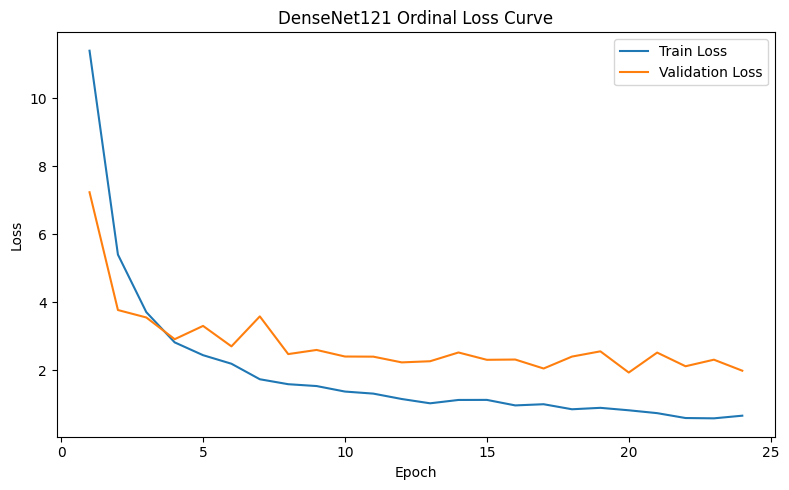

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_chen_ordinal_loss_loss_curve.png


In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Ordinal Loss Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_loss_curve.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


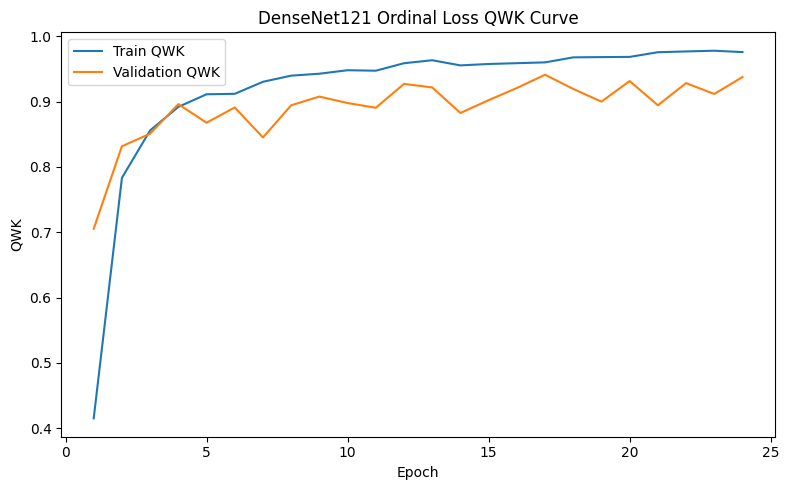

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_chen_ordinal_loss_qwk_curve.png


In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_qwk"], label="Train QWK")
plt.plot(history_df["epoch"], history_df["val_qwk"], label="Validation QWK")

plt.xlabel("Epoch")
plt.ylabel("QWK")
plt.title("DenseNet121 Ordinal Loss QWK Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_qwk_curve.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [15]:
test_loss, test_metrics, test_true, test_pred = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print("Test loss:", test_loss)
print_metrics(test_metrics, title="ordinal loss Test Metrics")


Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Test loss: 3.0965483788730337
ordinal loss Test Metrics
accuracy: 0.7755
macro_f1: 0.7472
weighted_f1: 0.7704
mae: 0.3061
qwk: 0.8640
total_errors: 66
adjacent_errors: 49
distant_errors: 17
total_error_rate: 0.2245
adjacent_error_rate: 0.1667
distant_error_rate: 0.0578


In [17]:
test_metrics_df = pd.DataFrame([{
    "experiment": EXPERIMENT_NAME,
    "loss": test_loss,
    "penalty_distance": PENALTY_DISTANCE,
    "square_loss": SQUARE_LOSS,
    "normalize_matrix": NORMALIZE_MATRIX,
    **test_metrics
}])

test_metrics_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_test_metrics.csv"
test_metrics_path.parent.mkdir(parents=True, exist_ok=True)

test_metrics_df.to_csv(test_metrics_path, index=False)

test_metrics_df




,experiment,loss,penalty_distance,square_loss,normalize_matrix,accuracy,macro_f1,weighted_f1,mae,qwk,total_errors,adjacent_errors,distant_errors,total_error_rate,adjacent_error_rate,distant_error_rate
0,densenet121_chen_ordinal_loss,3.096548,2,True,False,0.77551,0.747234,0.770378,0.306122,0.863973,66,49,17,0.22449,0.166667,0.057823


In [18]:
from sklearn.metrics import classification_report

report_dict = classification_report(
    test_true,
    test_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_classification_report.csv"
report_df.to_csv(report_path)

report_df


,precision,recall,f1-score,support
0Normal,0.815534,0.923077,0.865979,91.00000
1Doubtful,0.721649,0.795455,0.756757,88.00000
2Mild,0.586207,0.447368,0.507463,38.00000
3Moderate,0.843750,0.771429,0.805970,35.00000
4Severe,0.909091,0.714286,0.800000,42.00000
accuracy,0.775510,0.775510,0.775510,0.77551
macro avg,0.775246,0.730323,0.747234,294.00000
weighted avg,0.774516,0.775510,0.770378,294.00000


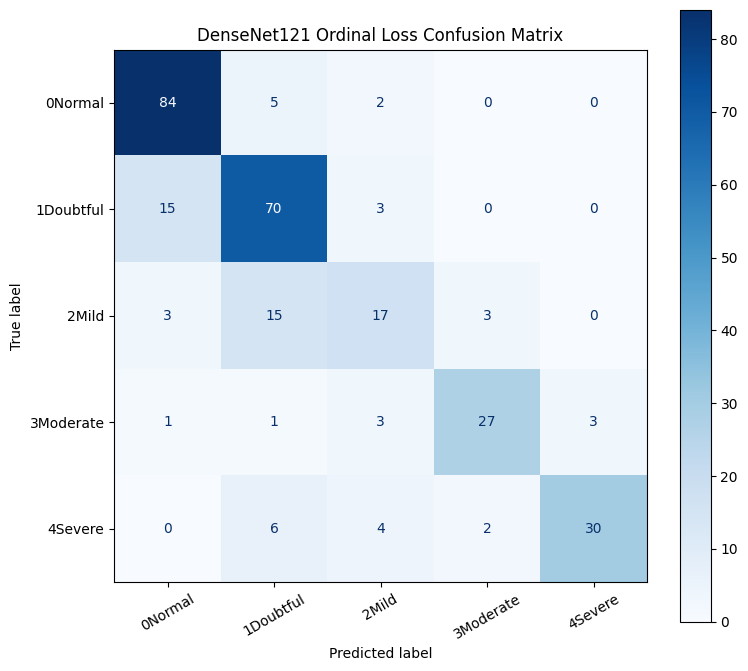

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_chen_ordinal_loss_confusion_matrix.png


In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = get_confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("DenseNet121 Ordinal Loss Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_confusion_matrix.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [20]:
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names],
)

cm_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_confusion_matrix.csv"
cm_df.to_csv(cm_path)

cm_df


,Pred_0Normal,Pred_1Doubtful,Pred_2Mild,Pred_3Moderate,Pred_4Severe
True_0Normal,84,5,2,0,0
True_1Doubtful,15,70,3,0,0
True_2Mild,3,15,17,3,0
True_3Moderate,1,1,3,27,3
True_4Severe,0,6,4,2,30


In [21]:
test_true_arr = np.array(test_true)
test_pred_arr = np.array(test_pred)

error_distance = np.abs(test_true_arr - test_pred_arr)

error_summary = {
    "experiment": EXPERIMENT_NAME,
    "total_samples": len(test_true_arr),
    "correct": int(np.sum(error_distance == 0)),
    "adjacent_errors": int(np.sum(error_distance == 1)),
    "distant_errors": int(np.sum(error_distance >= 2)),
    "max_error_distance": int(np.max(error_distance)),
    "mae": float(np.mean(error_distance)),
}

error_summary_df = pd.DataFrame([error_summary])

error_summary_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_error_distance.csv"
error_summary_df.to_csv(error_summary_path, index=False)

error_summary_df




,experiment,total_samples,correct,adjacent_errors,distant_errors,max_error_distance,mae
0,densenet121_chen_ordinal_loss,294,228,49,17,3,0.306122


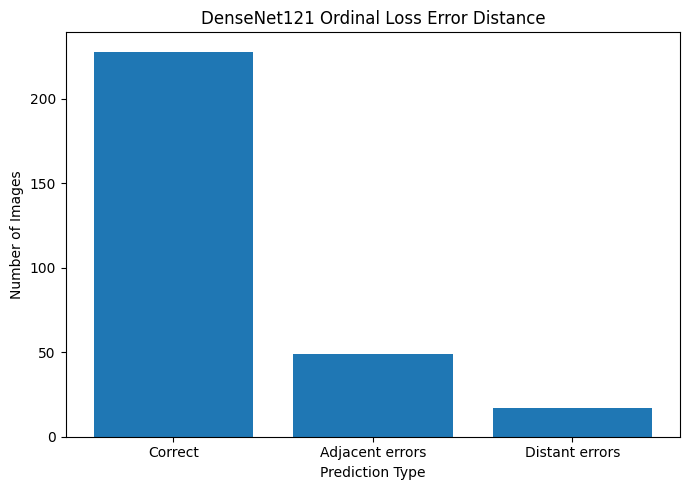

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_chen_ordinal_loss_error_distance.png


,error_type,count
0,Correct,228
1,Adjacent errors,49
2,Distant errors,17


In [22]:
error_distance_plot_df = pd.DataFrame([
    {"error_type": "Correct", "count": error_summary["correct"]},
    {"error_type": "Adjacent errors", "count": error_summary["adjacent_errors"]},
    {"error_type": "Distant errors", "count": error_summary["distant_errors"]},
])

plt.figure(figsize=(7, 5))

plt.bar(error_distance_plot_df["error_type"], error_distance_plot_df["count"])

plt.xlabel("Prediction Type")
plt.ylabel("Number of Images")
plt.title("DenseNet121 Ordinal Loss Error Distance")
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_error_distance.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

error_distance_plot_df
